In [2]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
print("✅ All NLTK data downloaded!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dispatch\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dispatch\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dispatch\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dispatch\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dispatch\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ All NLTK data downloaded!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

print("✅ Everything imported successfully!")

✅ Everything imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(f"✅ Data loaded!")
print(f"Total messages: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Data loaded!
Total messages: 5572

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


=== MESSAGE DISTRIBUTION ===
Normal (ham): 4825 messages (86.6%)
Spam:         747 messages (13.4%)

=== EXAMPLE NORMAL MESSAGES ===
  • Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  • Ok lar... Joking wif u oni...
  • U dun say so early hor... U c already then say...

=== EXAMPLE SPAM MESSAGES ===
  • Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  • FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
  • WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


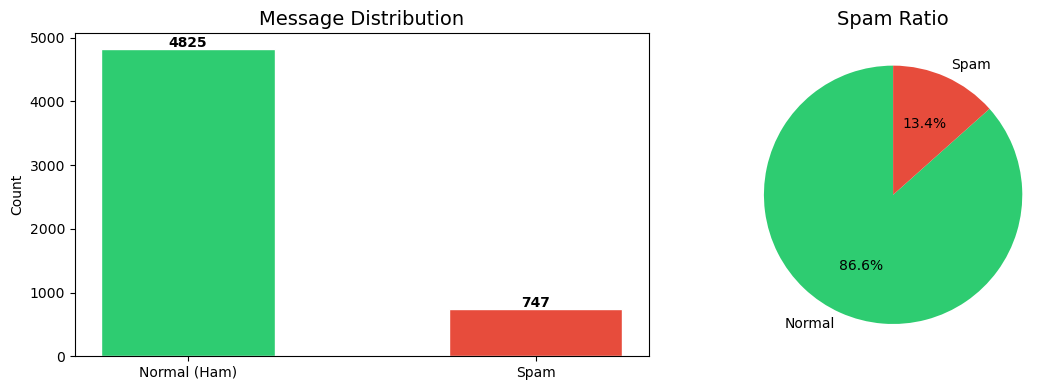

In [5]:
# Exploring data
counts = df['label'].value_counts()

print("=== MESSAGE DISTRIBUTION ===")
print(f"Normal (ham): {counts['ham']} messages ({counts['ham']/len(df)*100:.1f}%)")
print(f"Spam:         {counts['spam']} messages ({counts['spam']/len(df)*100:.1f}%)")

print("\n=== EXAMPLE NORMAL MESSAGES ===")
for msg in df[df['label']=='ham']['message'].head(3):
    print(f"  • {msg}")

print("\n=== EXAMPLE SPAM MESSAGES ===")
for msg in df[df['label']=='spam']['message'].head(3):
    print(f"  • {msg}")

# Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal (Ham)', 'Spam'],
            [counts['ham'], counts['spam']],
            color=['#2ECC71', '#E74C3C'],
            edgecolor='white', width=0.5)
axes[0].set_title('Message Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate([counts['ham'], counts['spam']]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie([counts['ham'], counts['spam']],
            labels=['Normal', 'Spam'],
            colors=['#2ECC71', '#E74C3C'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Spam Ratio', fontsize=14)

plt.tight_layout()
plt.show()

=== MESSAGE STATISTICS ===
       message_length  word_count
label                            
ham              71.5        14.3
spam            138.7        23.9

Spam with FREE/WIN/PRIZE: 445
Normal with FREE/WIN/PRIZE: 149


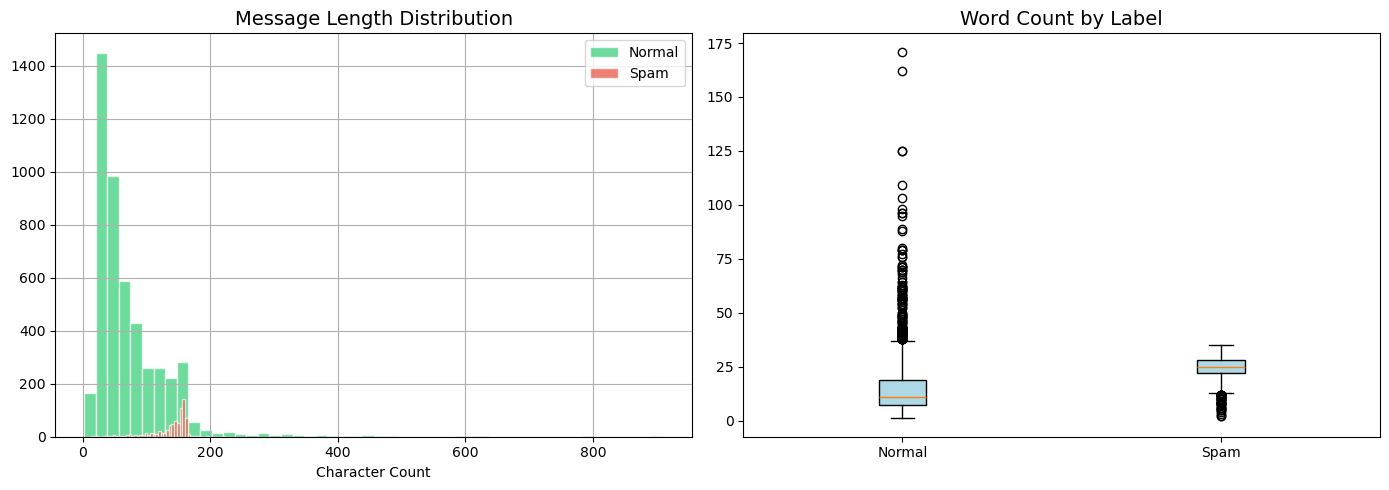

In [6]:
# Analyze message length
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['has_currency'] = df['message'].apply(
    lambda x: any(word in x.upper() 
                  for word in ['FREE', 'WIN', 'WINNER', 'PRIZE', '£', '$'])
)

print("=== MESSAGE STATISTICS ===")
print(df.groupby('label')[['message_length', 'word_count']].mean().round(1))

print(f"\nSpam with FREE/WIN/PRIZE: {df[df['label']=='spam']['has_currency'].sum()}")
print(f"Normal with FREE/WIN/PRIZE: {df[df['label']=='ham']['has_currency'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label']=='ham']['message_length'].hist(
    bins=50, ax=axes[0], alpha=0.7,
    color='#2ECC71', label='Normal', edgecolor='white')
df[df['label']=='spam']['message_length'].hist(
    bins=50, ax=axes[0], alpha=0.7,
    color='#E74C3C', label='Spam', edgecolor='white')
axes[0].set_title('Message Length Distribution', fontsize=14)
axes[0].set_xlabel('Character Count')
axes[0].legend()

spam_lengths = df[df['label']=='spam']['word_count']
ham_lengths = df[df['label']=='ham']['word_count']

axes[1].boxplot([ham_lengths, spam_lengths],
                labels=['Normal', 'Spam'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Word Count by Label', fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
# cleaning the text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: lowercase
    text = text.lower()
    
    # Step 2: remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 3: remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 4: tokenize
    words = text.split()
    
    # Step 5: remove stop words + lemmatize
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

# Show before and after
print("=== CLEANING EXAMPLES ===\n")
for msg in df['message'].head(4).tolist():
    cleaned = clean_text(msg)
    print(f"BEFORE: {msg[:70]}")
    print(f"AFTER:  {cleaned[:70]}")
    print()

# Apply to all messages
df['cleaned_message'] = df['message'].apply(clean_text)
print(f"✅ All {len(df)} messages cleaned!")
print(f"\nExample cleaned spam:")
print(df[df['label']=='spam']['cleaned_message'].head(3).tolist())

=== CLEANING EXAMPLES ===

BEFORE: Go until jurong point, crazy.. Available only in bugis n great world l
AFTER:  jurong point crazy available bugis great world buffet cine got amore w

BEFORE: Ok lar... Joking wif u oni...
AFTER:  lar joking wif oni

BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te
AFTER:  free entry wkly comp win cup final tkts may text receive entry questio

BEFORE: U dun say so early hor... U c already then say...
AFTER:  dun say early hor already say

✅ All 5572 messages cleaned!

Example cleaned spam:
['free entry wkly comp win cup final tkts may text receive entry questionstd txt ratetcs apply over', 'freemsg hey darling week word back like fun still xxx std chgs send rcv', 'winner valued network customer selected receivea prize reward claim call claim code valid hour']


In [8]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X = vectorizer.fit_transform(df['cleaned_message'])
y = (df['label'] == 'spam').astype(int)

print("=== TF-IDF MATRIX ===")
print(f"Total messages:              {X.shape[0]}")
print(f"Unique words/phrases:        {X.shape[1]}")
print(f"Spam messages:               {y.sum()}")
print(f"Normal messages:             {(y==0).sum()}")

# Show top spam words
feature_names = vectorizer.get_feature_names_out()
tfidf_sum = X.sum(axis=0).A1
top_indices = tfidf_sum.argsort()[-20:][::-1]

print(f"\nTop 20 most important words/phrases:")
for idx in top_indices:
    print(f"  • {feature_names[idx]}: {tfidf_sum[idx]:.2f}")

print("\n✅ Text converted to numbers!")

=== TF-IDF MATRIX ===
Total messages:              5572
Unique words/phrases:        5000
Spam messages:               747
Normal messages:             4825

Top 20 most important words/phrases:
  • call: 100.76
  • get: 77.46
  • come: 67.17
  • ill: 63.17
  • ltgt: 62.81
  • dont: 60.82
  • got: 59.11
  • know: 59.10
  • like: 57.30
  • good: 55.38
  • time: 54.91
  • going: 52.07
  • want: 51.27
  • day: 49.63
  • home: 49.19
  • lor: 48.77
  • free: 47.19
  • sorry: 46.02
  • one: 44.12
  • need: 44.06

✅ Text converted to numbers!


In [9]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== TRAIN TEST SPLIT ===")
print(f"Training messages: {X_train.shape[0]}")
print(f"Testing messages:  {X_test.shape[0]}")
print(f"\nTraining spam %:  {y_train.mean()*100:.1f}%")
print(f"Testing spam %:   {y_test.mean()*100:.1f}%")
print(f"\n✅ Same spam ratio in both — stratify worked!")

=== TRAIN TEST SPLIT ===
Training messages: 4457
Testing messages:  1115

Training spam %:  13.4%
Testing spam %:   13.4%

✅ Same spam ratio in both — stratify worked!


In [10]:
# Train all 3 models
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("=== TRAINING MODELS ===\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions) * 100
    results[name] = {
        'model': model,
        'predictions': predictions,
        'accuracy': accuracy
    }
    print(f"✅ {name}: {accuracy:.2f}% accuracy")

best = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Best model: {best} ({results[best]['accuracy']:.2f}%)")

=== TRAINING MODELS ===

✅ Naive Bayes: 98.03% accuracy
✅ Logistic Regression: 96.32% accuracy
✅ Random Forest: 97.85% accuracy

🏆 Best model: Naive Bayes (98.03%)


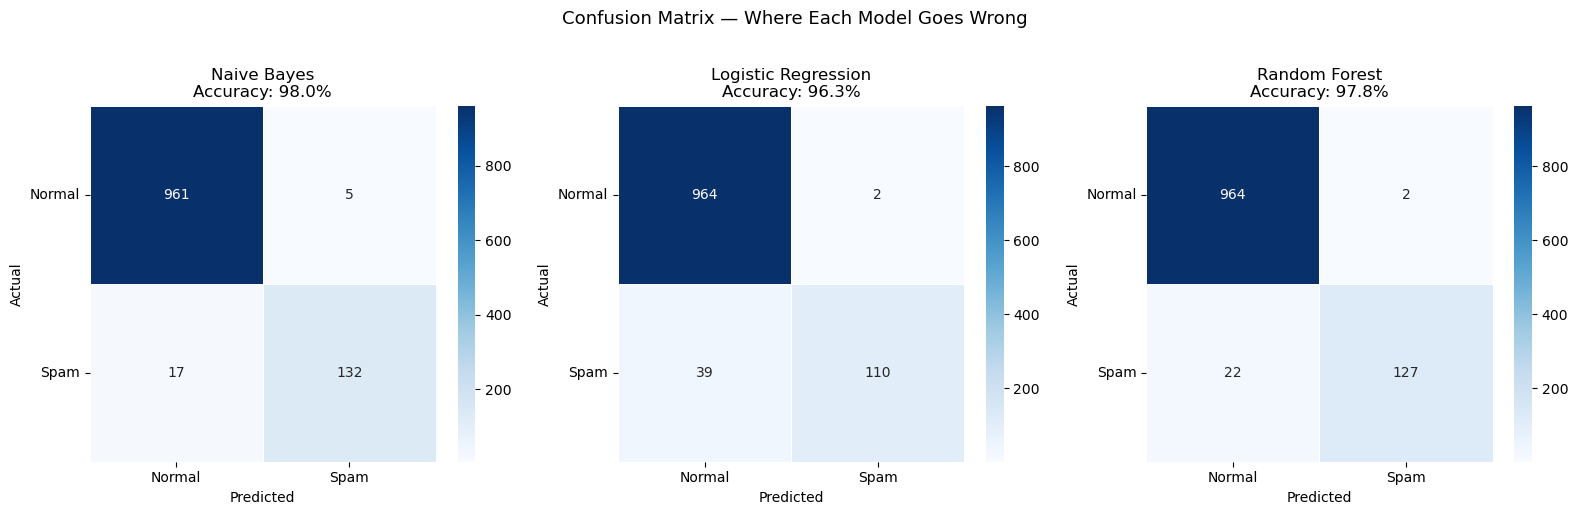


=== DETAILED REPORT — Naive Bayes ===
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       966
        Spam       0.96      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [11]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])

    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=axes[idx],
                linewidths=0.5)
    axes[idx].set_title(
        f'{name}\nAccuracy: {result["accuracy"]:.1f}%',
        fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Normal', 'Spam'])
    axes[idx].set_yticklabels(['Normal', 'Spam'], rotation=0)

plt.suptitle('Confusion Matrix — Where Each Model Goes Wrong',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n=== DETAILED REPORT — {best} ===")
print(classification_report(
    y_test,
    results[best]['predictions'],
    target_names=['Normal', 'Spam']
))

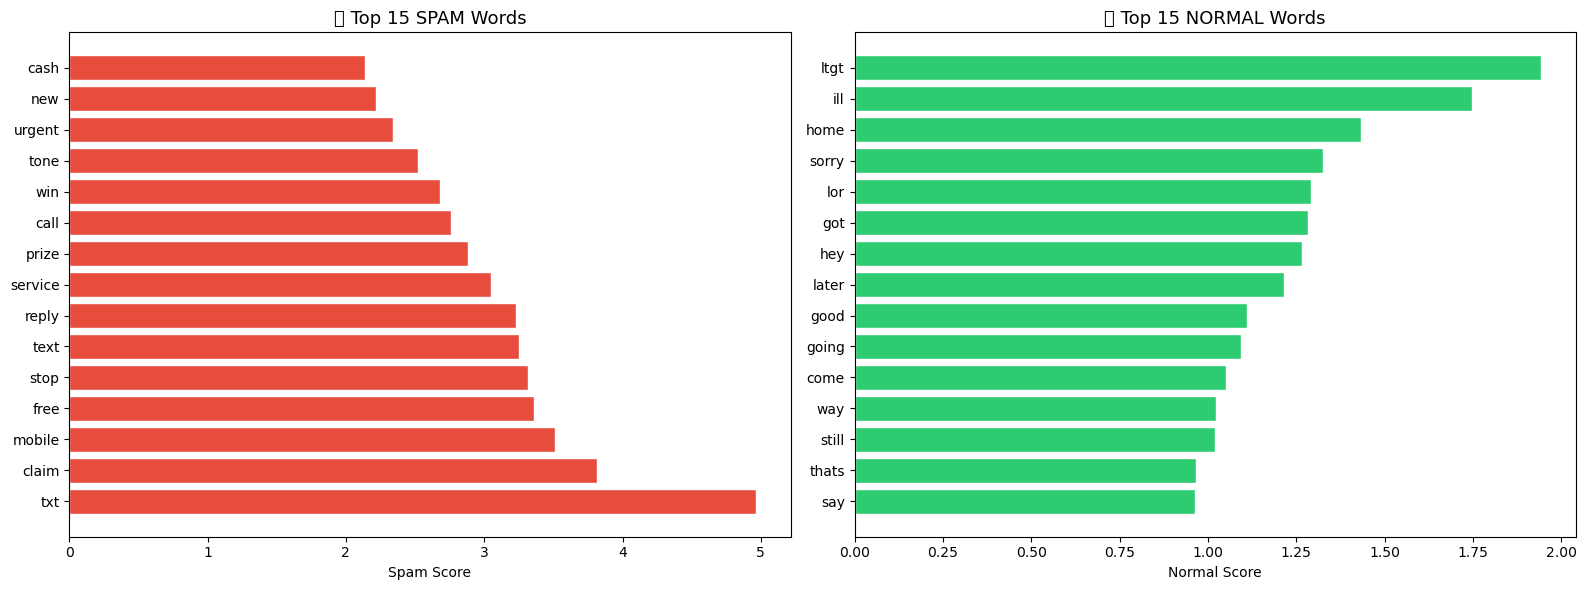

Top 10 spam trigger words:
  🚨 'txt' — spam score: 4.967
  🚨 'claim' — spam score: 3.814
  🚨 'mobile' — spam score: 3.511
  🚨 'free' — spam score: 3.359
  🚨 'stop' — spam score: 3.314
  🚨 'text' — spam score: 3.251
  🚨 'reply' — spam score: 3.232
  🚨 'service' — spam score: 3.050
  🚨 'prize' — spam score: 2.886
  🚨 'call' — spam score: 2.762


In [12]:
# What word screams spam?
lr_model = results['Logistic Regression']['model']
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
})

top_spam = coef_df.nlargest(15, 'coefficient')
top_ham = coef_df.nsmallest(15, 'coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_spam['word'],
             top_spam['coefficient'],
             color='#E74C3C', edgecolor='white')
axes[0].set_title('🚨 Top 15 SPAM Words', fontsize=13)
axes[0].set_xlabel('Spam Score')

axes[1].barh(top_ham['word'].tolist()[::-1],
             top_ham['coefficient'].abs().tolist()[::-1],
             color='#2ECC71', edgecolor='white')
axes[1].set_title('✅ Top 15 NORMAL Words', fontsize=13)
axes[1].set_xlabel('Normal Score')

plt.tight_layout()
plt.show()

print("Top 10 spam trigger words:")
for _, row in top_spam.head(10).iterrows():
    print(f"  🚨 '{row['word']}' — spam score: {row['coefficient']:.3f}")

In [13]:
# Spam checker function
def check_message(message):
    best_model_obj = results[best]['model']
    
    # Clean the message
    cleaned = clean_text(message)
    
    # Vectorize
    vectorized = vectorizer.transform([cleaned])
    
    # Predict
    prediction = best_model_obj.predict(vectorized)[0]
    probability = best_model_obj.predict_proba(vectorized)[0]
    
    # Display result
    label = "🚨 SPAM" if prediction == 1 else "✅ NORMAL"
    confidence = max(probability) * 100

    print(f"\n{'='*58}")
    print(f"MESSAGE: {message[:65]}{'...' if len(message)>65 else ''}")
    print(f"{'─'*58}")
    print(f"Result:      {label}")
    print(f"Confidence:  {confidence:.1f}%")
    print(f"Spam prob:   {probability[1]*100:.1f}%")
    print(f"Normal prob: {probability[0]*100:.1f}%")
    print(f"{'='*58}")

# Test with real messages
check_message("FREE entry in 2 a wkly comp to win FA Cup final tkts!")
check_message("Hey, are we still meeting for lunch tomorrow?")
check_message("URGENT! You have won a £1000 cash prize. Call NOW!")
check_message("Can you pick up some milk on your way home?")
check_message("Congratulations! You've been selected for a FREE iPhone!")
check_message("I'll be late tonight, don't wait up for dinner")


MESSAGE: FREE entry in 2 a wkly comp to win FA Cup final tkts!
──────────────────────────────────────────────────────────
Result:      🚨 SPAM
Confidence:  100.0%
Spam prob:   100.0%
Normal prob: 0.0%

MESSAGE: Hey, are we still meeting for lunch tomorrow?
──────────────────────────────────────────────────────────
Result:      ✅ NORMAL
Confidence:  100.0%
Spam prob:   0.0%
Normal prob: 100.0%

MESSAGE: URGENT! You have won a £1000 cash prize. Call NOW!
──────────────────────────────────────────────────────────
Result:      🚨 SPAM
Confidence:  99.9%
Spam prob:   99.9%
Normal prob: 0.1%

MESSAGE: Can you pick up some milk on your way home?
──────────────────────────────────────────────────────────
Result:      ✅ NORMAL
Confidence:  99.9%
Spam prob:   0.1%
Normal prob: 99.9%

MESSAGE: Congratulations! You've been selected for a FREE iPhone!
──────────────────────────────────────────────────────────
Result:      🚨 SPAM
Confidence:  84.2%
Spam prob:   84.2%
Normal prob: 15.8%

MESSAGE: I'll